In [42]:
df=pd.read_csv("data/customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [19]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [20]:
df.columns=df.columns.str.strip()

In [21]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")
df=df.dropna()

In [22]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

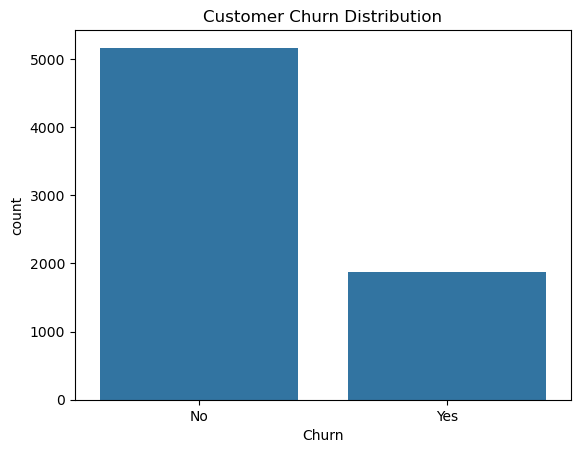

In [23]:
sns.countplot(x="Churn",data=df)
plt.title("Customer Churn Distribution")
plt.show()

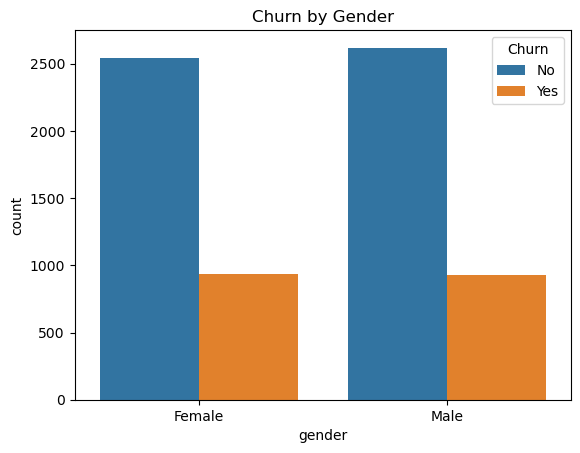

In [34]:
sns.countplot(x="Churn",data=df)
plt.title("Customer Churn Distribution")
plt.savefig("outputs/churn_distribution.png")
plt.close()
sns.countplot(x="gender",hue="Churn",data=df)
plt.title("Churn by Gender")
plt.show()

In [35]:
plt.figure()
sns.boxplot(x="Churn",y="tenure",data=df)
plt.title("Tenure vs Churn")
plt.savefig("outputs/tenure_vs_churn.png")
plt.close()
churn_rate=df["Churn"].value_counts(normalize=True)*100
churn_rate

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [26]:
insights = """
Customer Churn Analysis

Key Insights:
1.Customers with month-to-month contracts show the highest churn.
2.Customers with higher monthly charges tend to churn more.
3.Customers with lower tenure have higher churn probability.
4.Gender does not significantly affect churn.

Recommendations:
•Provide long-term contract discounts.
•Offer loyalty programs for long-term customers.
•Reduce monthly charges for high-risk customers.
•Improve onboarding experience for new customers.
"""
print(insights)


Customer Churn Analysis

Key Insights:
1.Customers with month-to-month contracts show the highest churn.
2.Customers with higher monthly charges tend to churn more.
3.Customers with lower tenure have higher churn probability.
4.Gender does not significantly affect churn.

Recommendations:
•Provide long-term contract discounts.
•Offer loyalty programs for long-term customers.
•Reduce monthly charges for high-risk customers.
•Improve onboarding experience for new customers.



In [32]:
with open("outputs/churn_insights.txt","w") as f:
    f.write(insights)
print("Insights saved successfully.")

Insights saved successfully.


In [33]:
import os
os.listdir("outputs")

['churn_insights.txt']

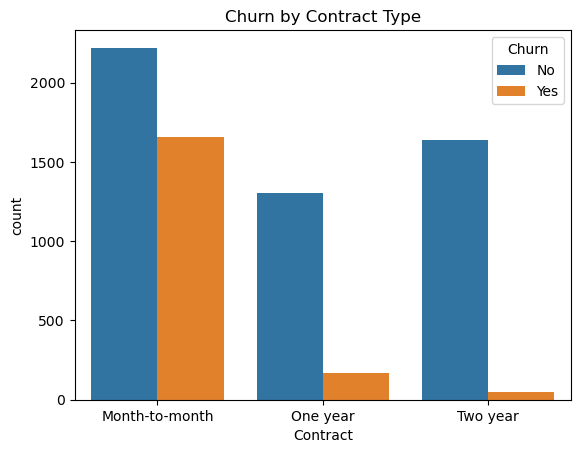

In [36]:
plt.figure()
sns.countplot(x="gender",hue="Churn",data=df)
plt.title("Churn by Gender")
plt.savefig("outputs/churn_by_gender.png")
plt.close()
sns.countplot(x="Contract",hue="Churn",data=df)
plt.title("Churn by Contract Type")
plt.show()

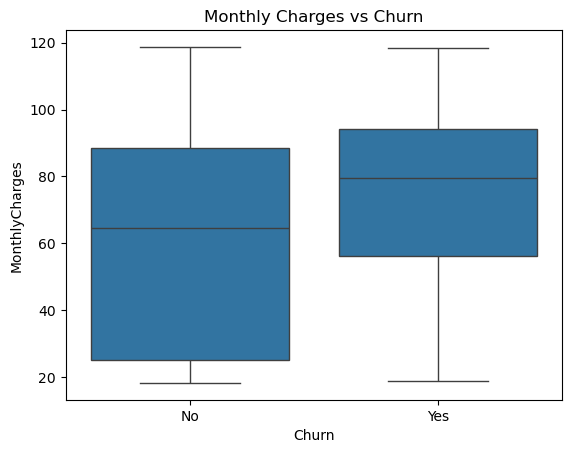

In [37]:
plt.figure()
sns.countplot(x="Contract",hue="Churn",data=df)
plt.title("Churn by Contract Type")
plt.savefig("outputs/churn_by_contract.png")
plt.close()
sns.boxplot(x="Churn",y="MonthlyCharges",data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

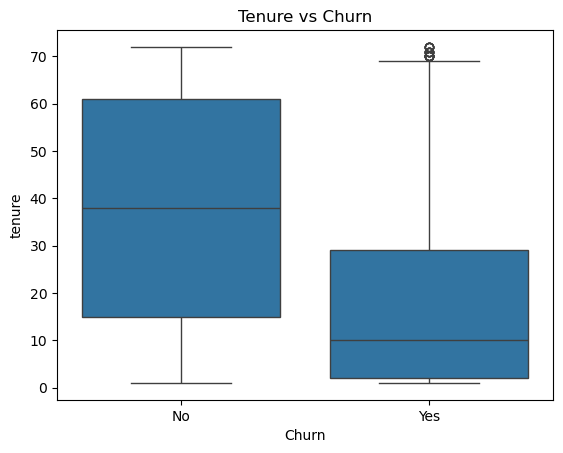

In [38]:
plt.figure()
sns.boxplot(x="Churn",y="MonthlyCharges",data=df)
plt.title("Monthly Charges vs Churn")
plt.savefig("outputs/monthlycharges_vs_churn.png")
plt.close()
sns.boxplot(x="Churn",y="tenure",data=df)
plt.title("Tenure vs Churn")
plt.show()

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns